# 320 — Final Feature Set 확정 (lv3 강건성 기반)

**목적**: 16 non-null features 중 추가 5 features 평가 + 5 확정 features 재평가 → final feature set 확정.

**4 그룹**:

| 그룹 | n (baseline) | 비고 |
|---|---|---|
| lv2_human | 51 | 보겸 1인 |
| lv2_macro | 101 | lv2_collector 산출 |
| Balabit_human (`balabit`) | 500 | Balabit derived |
| lv3_balabit_kde | 50 | KDE 매크로 산출 |

**평가 5 추가 features** (Balabit 결측 6 + keyboard 10 배제 후 11-6=5):
- `mouse_acceleration_mean`
- `mouse_jerk_mean`
- `mouse_path_straightness_score`
- `mouse_direction_change_count`
- `mouse_total_travel_distance_px`

**5 확정 features** (315 결과 4/5 도미노 깨짐 — 320-B 에서 함께 재평가):
- `inter_click_interval_ms`
- `mouse_speed_change_mean`
- `mouse_max_speed_px_per_ms`
- `mouse_path_curvature_mean`
- `mouse_avg_speed_px_per_ms`

**가설**: 추가 5 중 일부가 lv3 vs Balabit 비교에서도 분리력 유지 → 강건 신호 후보.

**Caveats**:
- `[min, max]` 실측 range 기반 외부진입율 — outlier 1개로 range 폭 부풀려질 수 있음. 결과 해석 시 group min/max 절대값 함께 검토 (`320pool-03-stats` 별도 표).
- σ ratio 방향: `macro_std / human_std` (작을수록 macro 좁음, 핸드오프 baseline 0.136 정합).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EDA_DIR = Path.cwd()
if str(EDA_DIR) not in sys.path:
    sys.path.insert(0, str(EDA_DIR))

from trial_loader import list_trials_by_group, load_trial

NEW_FEATURES = [
    "mouse_acceleration_mean",
    "mouse_jerk_mean",
    "mouse_path_straightness_score",
    "mouse_direction_change_count",
    "mouse_total_travel_distance_px",
]

CONFIRMED_FEATURES = [
    "inter_click_interval_ms",
    "mouse_speed_change_mean",
    "mouse_max_speed_px_per_ms",
    "mouse_path_curvature_mean",
    "mouse_avg_speed_px_per_ms",
]

ALL_FEATURES = NEW_FEATURES + CONFIRMED_FEATURES  # 10 (320-B 에서 재사용)

GROUPS = ["lv2_human", "lv2_macro", "balabit", "lv3_balabit_kde"]
BASELINE_N = {"lv2_human": 51, "lv2_macro": 101, "balabit": 500, "lv3_balabit_kde": 50}

GROUP_COLORS = {
    "lv2_human": "steelblue",
    "lv2_macro": "crimson",
    "balabit": "seagreen",
    "lv3_balabit_kde": "darkorange",
}

In [2]:
def load_metrics_df(group: str, features: list[str]) -> pd.DataFrame:
    metas = list_trials_by_group(group)
    rows = []
    for m in metas:
        trial = load_trial(m["trial_id"])
        metrics = trial.get("metrics", {})
        row = {
            "trial_id": m["trial_id"],
            "group": group,
            "label": m.get("label"),
        }
        for f in features:
            row[f] = metrics.get(f)
        rows.append(row)
    return pd.DataFrame(rows)

dfs = {g: load_metrics_df(g, ALL_FEATURES) for g in GROUPS}
df_all = pd.concat(dfs.values(), ignore_index=True)

print("Group counts:")
for g in GROUPS:
    n = len(dfs[g])
    base = BASELINE_N[g]
    delta = n - base
    if delta == 0:
        print(f"  [ok] {g}: n={n} (baseline {base})")
    else:
        sign = "+" if delta > 0 else ""
        print(f"  [delta] {g}: n={n} (Δ={sign}{delta} vs baseline {base})")

print()
print(f"Total rows: {len(df_all)} (expected {sum(BASELINE_N.values())})")

Group counts:
  [ok] lv2_human: n=51 (baseline 51)
  [ok] lv2_macro: n=101 (baseline 101)
  [ok] balabit: n=500 (baseline 500)
  [ok] lv3_balabit_kde: n=50 (baseline 50)

Total rows: 702 (expected 702)


In [3]:
print("NaN counts (additional 5 features × 4 groups):")
nan_problem = False
for f in NEW_FEATURES:
    print(f"  {f}:")
    for g in GROUPS:
        n_nan = int(dfs[g][f].isna().sum())
        n_total = len(dfs[g])
        marker = "" if n_nan == 0 else "  >>> NaN <<<"
        print(f"    {g}: {n_nan}/{n_total}{marker}")
        if n_nan > 0:
            nan_problem = True

if nan_problem:
    raise RuntimeError(
        "NaN found in additional 5 features × 4 groups. "
        "Stop and report to analysis chat. Self-imputation prohibited."
    )

print()
print("[ok] All 5 additional features non-null across 4 groups.")

NaN counts (additional 5 features × 4 groups):
  mouse_acceleration_mean:
    lv2_human: 0/51
    lv2_macro: 0/101
    balabit: 0/500
    lv3_balabit_kde: 0/50
  mouse_jerk_mean:
    lv2_human: 0/51
    lv2_macro: 0/101
    balabit: 0/500
    lv3_balabit_kde: 0/50
  mouse_path_straightness_score:
    lv2_human: 0/51
    lv2_macro: 0/101
    balabit: 0/500
    lv3_balabit_kde: 0/50
  mouse_direction_change_count:
    lv2_human: 0/51
    lv2_macro: 0/101
    balabit: 0/500
    lv3_balabit_kde: 0/50
  mouse_total_travel_distance_px:
    lv2_human: 0/51
    lv2_macro: 0/101
    balabit: 0/500
    lv3_balabit_kde: 0/50

[ok] All 5 additional features non-null across 4 groups.


## 2. 추가 5 features × 4 그룹 분포 시각화

각 feature 별 4 그룹 overlay histogram (density). 그룹 평균은 점선으로 표시.

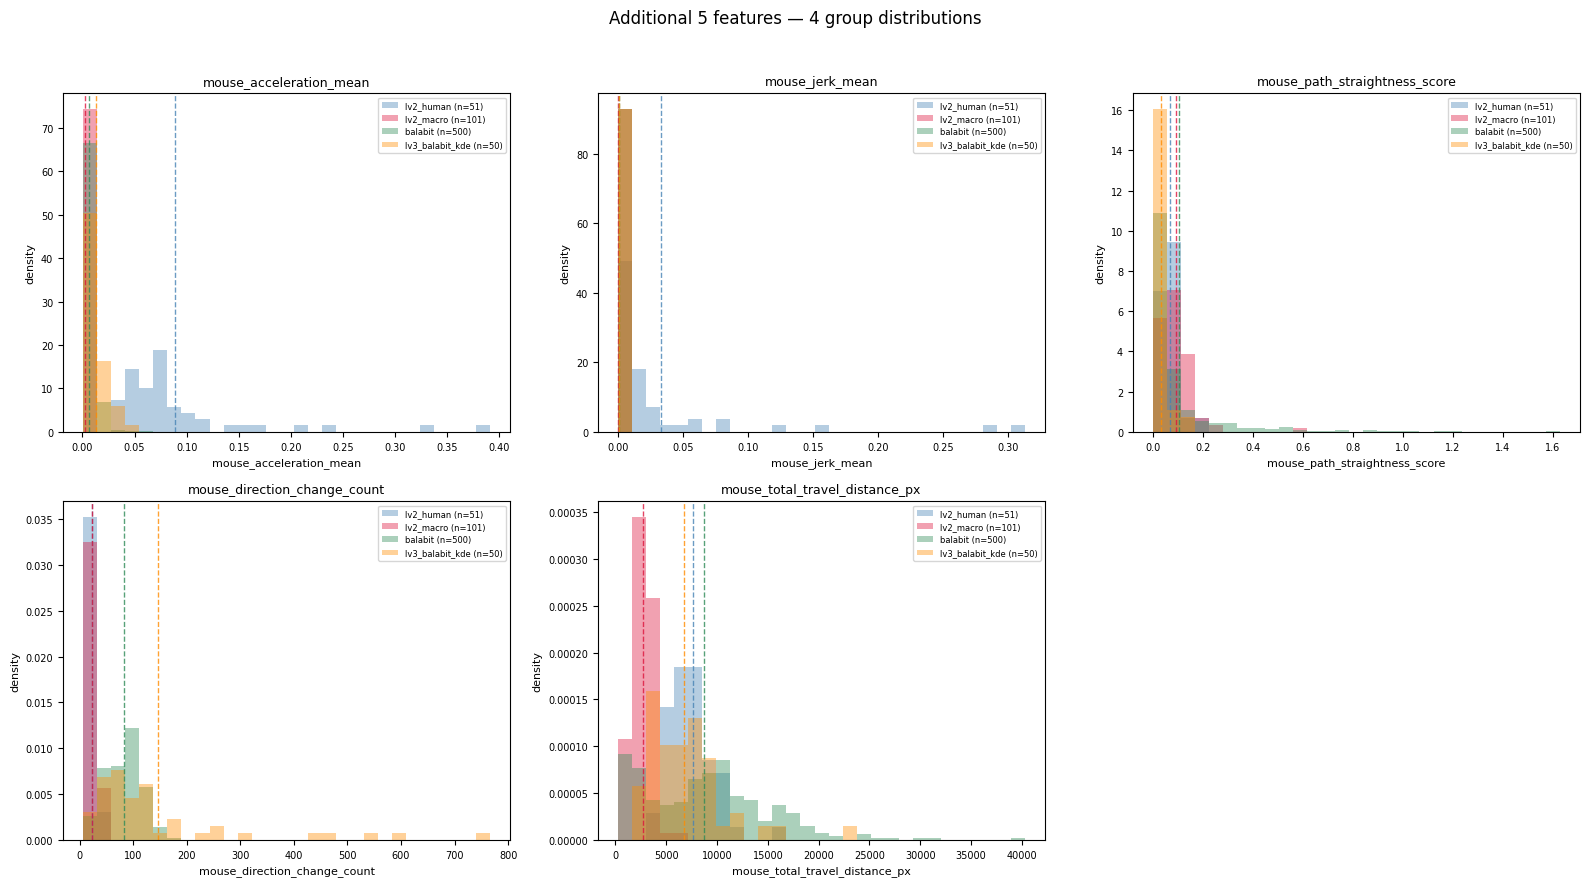

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

for i, feat in enumerate(NEW_FEATURES):
    ax = axes_flat[i]
    values = {g: dfs[g][feat].dropna().values for g in GROUPS}
    combined = np.concatenate(list(values.values()))
    bins = np.linspace(combined.min(), combined.max(), 30)

    for g in GROUPS:
        v = values[g]
        ax.hist(v, bins=bins, alpha=0.4, color=GROUP_COLORS[g],
                label=f"{g} (n={len(v)})", density=True)
        ax.axvline(np.mean(v), color=GROUP_COLORS[g], linestyle="--",
                   linewidth=1.0, alpha=0.8)

    ax.set_title(feat, fontsize=9)
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel("density", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)

axes_flat[5].axis("off")
fig.suptitle("Additional 5 features — 4 group distributions", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 3. per-group [min, max] + 외부진입율 (두 축) + σ ratio + group min/max 절대값

**축1 (lv2)**: `lv2_macro` [min, max] range → `lv2_human` inside / below / above 비율 (human 다양성 척도)
**축2 (lv3)**: `Balabit_human` [min, max] range → `lv3_balabit_kde` inside / below / above 비율 (lv3 흉내 척도)

비대칭 정당화: 축1 은 macro 좁은 분포가 human 폭을 얼마나 못 잡는지(human 다양성), 축2 는 lv3 매크로가 Balabit_human 폭 안에 얼마나 들어가는지(lv3 흉내). 측정 의도가 다름.

**σ ratio 방향**: `macro_std / human_std` (작을수록 macro 좁음). 핸드오프 baseline 0.136 정합.
- 축1: `lv2_macro_std / lv2_human_std`
- 축2: `lv3_balabit_kde_std / Balabit_human_std`

**Caveat**: `[min, max]` 실측 range 는 outlier 1개로 폭 부풀려질 수 있음. 결과 해석 시 group min/max 절대값 함께 검토 (마지막 표).

In [5]:
def coverage(reference_vals: np.ndarray, target_vals: np.ndarray) -> dict:
    r_min, r_max = float(reference_vals.min()), float(reference_vals.max())
    pct_below  = float((target_vals < r_min).sum()) / len(target_vals) * 100
    pct_above  = float((target_vals > r_max).sum()) / len(target_vals) * 100
    pct_inside = 100 - pct_below - pct_above
    return {
        "ref_min": r_min,
        "ref_max": r_max,
        "pct_below": pct_below,
        "pct_inside": pct_inside,
        "pct_above": pct_above,
    }

def std_ratio_macro_over_human(macro_vals: np.ndarray, human_vals: np.ndarray) -> float:
    h_std = float(np.std(human_vals))
    m_std = float(np.std(macro_vals))
    return (m_std / h_std) if h_std > 0 else float("inf")

def axis1_row(feat: str) -> dict:
    vh = dfs["lv2_human"][feat].dropna().values
    vm = dfs["lv2_macro"][feat].dropna().values
    cov = coverage(vm, vh)
    return {
        "feature": feat,
        "macro_min": cov["ref_min"],
        "macro_max": cov["ref_max"],
        "human_below%": cov["pct_below"],
        "human_inside%": cov["pct_inside"],
        "human_above%": cov["pct_above"],
        "std_ratio_m/h": std_ratio_macro_over_human(vm, vh),
    }

def axis2_row(feat: str) -> dict:
    vbh  = dfs["balabit"][feat].dropna().values
    vlv3 = dfs["lv3_balabit_kde"][feat].dropna().values
    cov = coverage(vbh, vlv3)
    return {
        "feature": feat,
        "balabit_min": cov["ref_min"],
        "balabit_max": cov["ref_max"],
        "lv3_below%": cov["pct_below"],
        "lv3_inside%": cov["pct_inside"],
        "lv3_above%": cov["pct_above"],
        "std_ratio_lv3/balabit": std_ratio_macro_over_human(vlv3, vbh),
    }

def group_minmax_row(feat: str) -> dict:
    row = {"feature": feat}
    for g in GROUPS:
        v = dfs[g][feat].dropna().values
        row[f"{g}_min"] = float(v.min())
        row[f"{g}_max"] = float(v.max())
    return row

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

axis1_df = pd.DataFrame([axis1_row(f) for f in NEW_FEATURES]).set_index("feature")
axis2_df = pd.DataFrame([axis2_row(f) for f in NEW_FEATURES]).set_index("feature")
abs_df   = pd.DataFrame([group_minmax_row(f) for f in NEW_FEATURES]).set_index("feature")

print("=== 축1 (lv2): lv2_macro range -> lv2_human inside/below/above ===")
print(axis1_df.to_string(float_format=lambda x: f"{x:.4g}"))

print()
print("=== 축2 (lv3): Balabit_human range -> lv3_balabit_kde inside/below/above ===")
print(axis2_df.to_string(float_format=lambda x: f"{x:.4g}"))

print()
print("=== group min/max 절대값 (outlier 검토용) ===")
print(abs_df.to_string(float_format=lambda x: f"{x:.4g}"))

=== 축1 (lv2): lv2_macro range -> lv2_human inside/below/above ===
                                macro_min  macro_max  human_below%  human_inside%  human_above%  std_ratio_m/h
feature                                                                                                       
mouse_acceleration_mean          0.001725   0.003087             0              0           100       0.003751
mouse_jerk_mean                   4.4e-05   0.000102             0              0           100      0.0001563
mouse_path_straightness_score    0.005676     0.5953         3.922          96.08             0          1.791
mouse_direction_change_count            7         40             0            100             0           1.28
mouse_total_travel_distance_px      927.1       5828             0          25.49         74.51         0.4188

=== 축2 (lv3): Balabit_human range -> lv3_balabit_kde inside/below/above ===
                                balabit_min  balabit_max  lv3_below%  lv3_inside